<a href="https://colab.research.google.com/github/Gute-Git/League-of-Legends-Ranked-Gameplay-Analysis/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

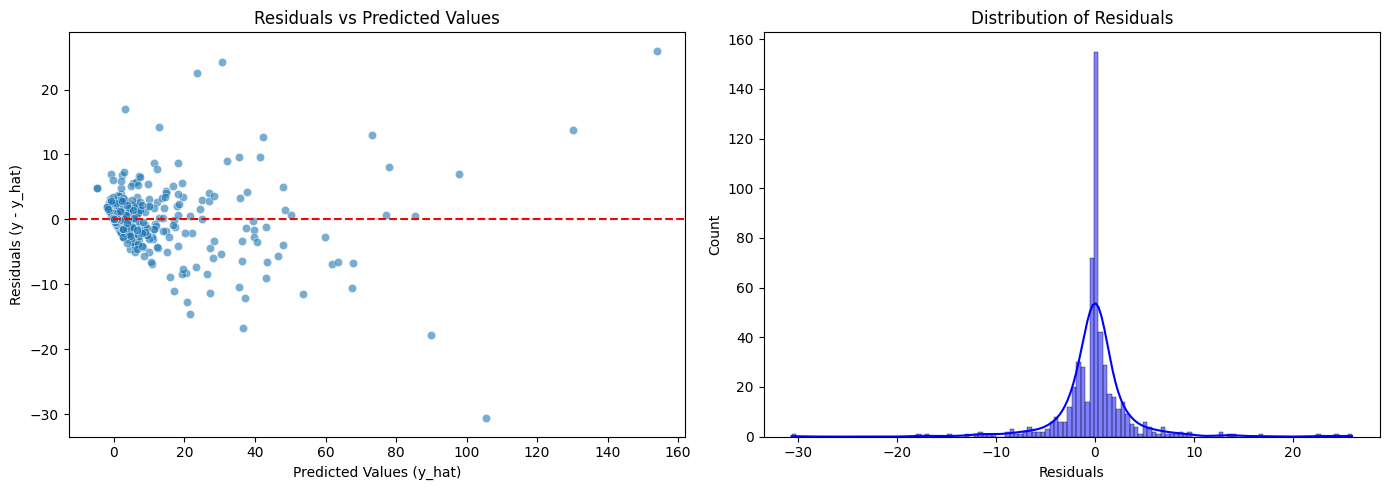

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

# 1. טעינת הנתונים
df = pd.read_csv('dataset - 2020-09-24.csv')

# בחירת משתנה המטרה לרגרסיה (כמות שערים)
target_col = 'Goals'

# נבחר רק את העמודות המספריות ונמלא ערכים חסרים באפס כדי למנוע שגיאות
df_numeric = df.select_dtypes(include=[np.number]).fillna(0)

# נסיר את משתנה המטרה ועמודות שיכולות לגרום ל"דליפת מידע" מתוך הפיצ'רים
cols_to_drop = [target_col, 'Jersey Number', 'Goals per match', 'Headed goals',
                'Goals with right foot', 'Goals with left foot', 'Penalties scored', 'Freekicks scored']
X = df_numeric.drop(columns=[col for col in cols_to_drop if col in df_numeric.columns])
y = df_numeric[target_col]

# 2. הגדרת מודל רגרסיה ליניארית ו-K-Fold Cross Validation
# נבחר K=5 משיקולי Bias-Variance וזמן ריצה לדאטהסט בינוני
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()

# יצירת תחזיות בעזרת אימות צולב (Cross-Validation)
y_pred = cross_val_predict(model, X, y, cv=kf)

# 3. חישוב השאריות (Residuals) כפי שנדרש: y - y_hat
residuals = y - y_pred

# 4. ויזואליזציה (מענה לסעיף 1.1 במטלה)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# גרף 1: שאריות כנגד ערכים חזויים
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0], alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Values (y_hat)')
axes[0].set_ylabel('Residuals (y - y_hat)')

# גרף 2: התפלגות השאריות (היסטוגרמה)
sns.histplot(residuals, kde=True, ax=axes[1], color='blue')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

### חלק 1: ניתוח שאריות ברגרסיה (Regression Error Analysis)

#### סעיף 1.1: ניתוח שאריות (Residual Analysis)
בשלב זה התחלנו את ניתוח השאריות. בחרנו את עמודת ה-Goals (שערים) כמשתנה המטרה שלנו לרגרסיה. כדי למנוע דליפת מידע (Data Leakage), הסרנו מהפיצ'רים המסבירים עמודות המייצגות סוגי שערים ספציפיים או חישובים ישירים שלהם.

**הצדקת בחירת ה-K עבור ה-Cross Validation:**
בחרנו ב-K=5 עבור תהליך האימות הצולב. מכיוון שהדאטהסט מכיל כ-570 שורות (גודל קטן-בינוני), חלוקה ל-5 קבוצות מספקת איזון מצוין של ה-Bias-Variance Trade-off. חלוקה זו משאירה בכל איטרציה כ-80% מהנתונים לצורך אימון המודל, מונעת התאמת-יתר (Overfitting) ושומרת על יעילות חישובית וזמן ריצה קצר.

**תשובות לשאלות הניתוח:**
* **האם השאריות מרוכזות סביב האפס?** על פי היסטוגרמת השאריות, ניתן להבחין כי מרכז ההתפלגות והמסה העיקרית של השגיאות אכן מרוכזים וממוקדים סביב קו ה-0.
* **האם השאריות מציגות תבנית שיטתית?** בגרף הפיזור (Scatter plot) ניתן להבחין בפסים אלכסוניים ברורים ואי-אקראיות. דפוס זה נובע מכך שמשתנה המטרה מורכב ממספרים שלמים בלבד (כמות שערים אבסולוטית), לצד כמות גדולה של ערכי 0 עבור שחקני הגנה ושוערים, דבר המקשה על מודל רציף וליניארי.
* **האם יש עדות להטרוסקדסטיות (Heteroscedasticity)?** כן. גרף הפיזור מראה בבירור כי ככל שהערכים החזויים גבוהים יותר, כך פיזור הנקודות הולך ומתרחב בצורת "מניפה". משמעות הדבר היא ששונות השגיאה אינה קבועה, וזוהי עדות מובהקת להטרוסקדסטיות.



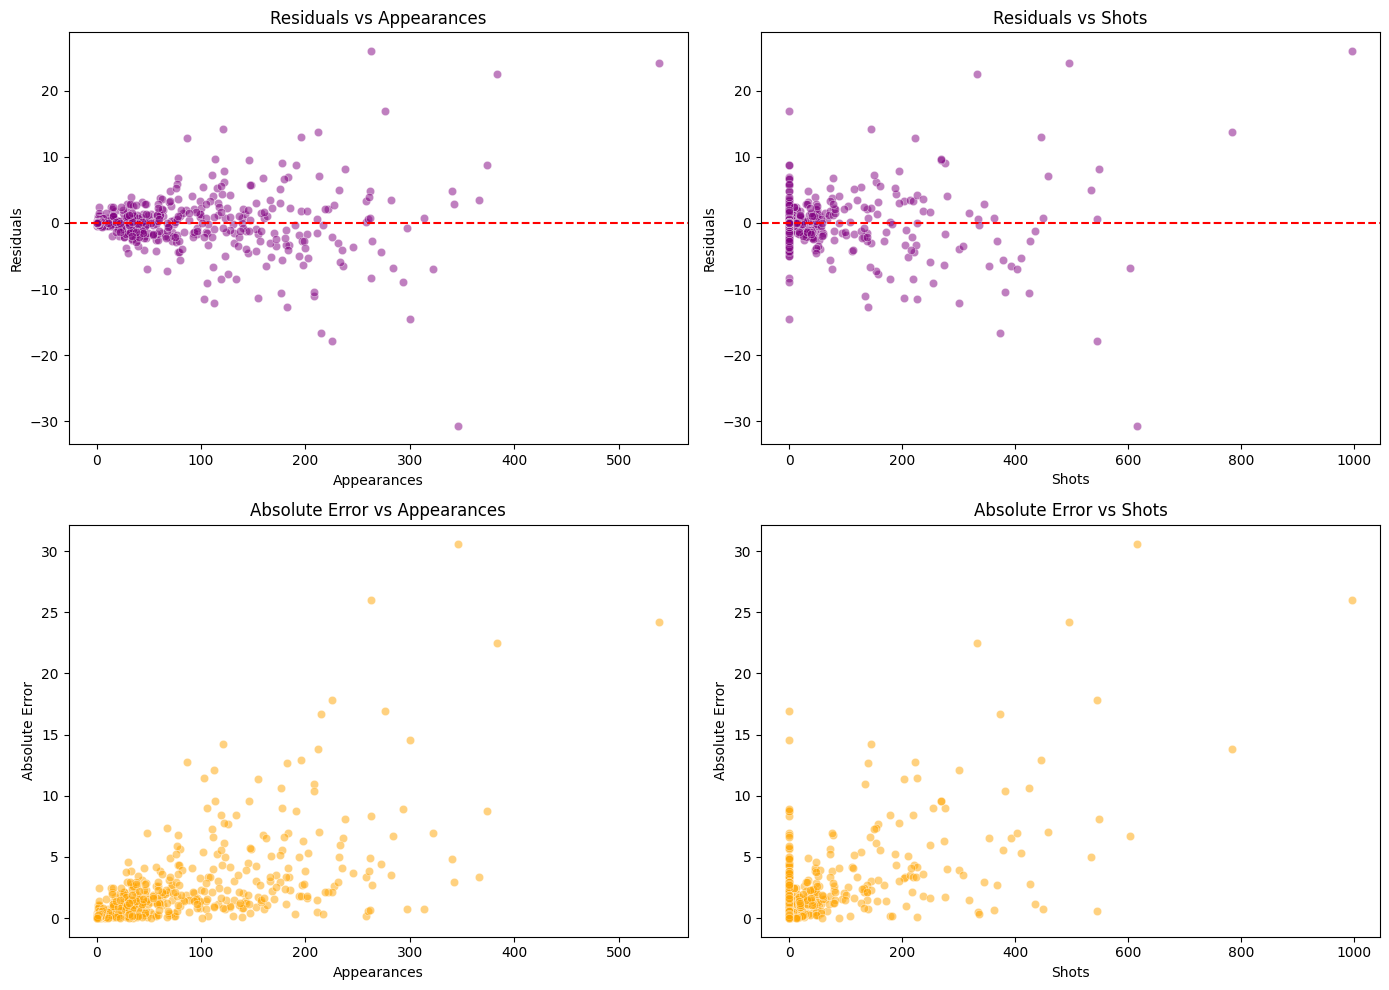

In [2]:
# 1.2 Error as a Function of Features

# חישוב השגיאה המוחלטת (Absolute Errors)
abs_errors = np.abs(residuals)

# נבחר שני פיצ'רים מעניינים מהדאטה כדי לנתח את השגיאה מולם
features_to_plot = ['Appearances', 'Shots']

# יצירת גרפים: 2 שורות (שאריות, שגיאה מוחלטת) על 2 עמודות (הפיצ'רים שבחרנו)
fig, axes = plt.subplots(2, len(features_to_plot), figsize=(14, 10))

for i, feature in enumerate(features_to_plot):
    # שורה ראשונה: הפיצ'ר מול השאריות
    sns.scatterplot(x=X[feature], y=residuals, ax=axes[0, i], alpha=0.5, color='purple')
    axes[0, i].axhline(y=0, color='r', linestyle='--')
    axes[0, i].set_title(f'Residuals vs {feature}')
    axes[0, i].set_xlabel(feature)
    axes[0, i].set_ylabel('Residuals')

    # שורה שנייה: הפיצ'ר מול השגיאה המוחלטת
    sns.scatterplot(x=X[feature], y=abs_errors, ax=axes[1, i], alpha=0.5, color='orange')
    axes[1, i].set_title(f'Absolute Error vs {feature}')
    axes[1, i].set_xlabel(feature)
    axes[1, i].set_ylabel('Absolute Error')

plt.tight_layout()
plt.show()


#### סעיף 1.2: השגיאה כפונקציה של פיצ'רים (Error as a Function of Features)
בסעיף זה בחנו את התנהגות השאריות והשגיאות המוחלטות (Absolute Errors) ביחס לשני פיצ'רים מרכזיים: הופעות (Appearances) ובעיטות (Shots).

**ממצאים מרכזיים מתוך הגרפים:**
* **קשרים ותבניות תלויות-פיצ'ר:** בגרפים של הפיצ'ר Shots מול השאריות, ניתן לראות בבירור שככל שכמות הבעיטות גדלה, כך גדל גם טווח השגיאה של המודל. עבור שחקנים עם מעט בעיטות (הצד השמאלי של הגרף), השגיאה קטנה ומרוכזת מאוד. לעומת זאת, עבור שחקנים שמרבים לבעוט, המודל נוטה לטעות בטווחים גדולים יותר.
* **שונות בלתי קבועה:** הגרפים בשורה התחתונה (שגיאה מוחלטת) ממחישים שונות שהולכת וגדלה – ככל שערכי הפיצ'רים עולים (יותר הופעות או יותר בעיטות), כך השגיאה המוחלטת הממוצעת נוטה לגדול וליצור צורת "משפך" (Fan-shape). המודל הליניארי מתקשה לדייק עבור הערכים הגבוהים.
* **תתי-אוכלוסיות נסתרות (Hidden Subpopulations):** הפיזור הרחב בערכים הגבוהים מצביע על תתי-קבוצות באוכלוסייה. שחקני התקפה (חלוצים וקשרים התקפיים) צוברים הרבה בעיטות והופעות ומתאפיינים בשונות גבוהה של הבקעות, בעוד ששחקני הגנה שצוברים הופעות שומרים על סטטיסטיקת הבקעות קרובה לאפס. המודל הליניארי הכללי אינו מצליח להפריד בין תתי-הקבוצות הללו בצורה מיטבית.

/tmp/ipykernel_14209/1370664657.py:22: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=[X_normal[feature], X_extreme[feature]], ax=axes[i], palette=['#3498db', '#e74c3c'])
/tmp/ipykernel_14209/1370664657.py:22: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=[X_normal[feature], X_extreme[feature]], ax=axes[i], palette=['#3498db', '#e74c3c'])
/tmp/ipykernel_14209/1370664657.py:22: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=[X_normal[feature], X_extreme[feature]], ax=axes[i], palette=['#3498db', '#e74c3c'])
/tmp/ipykernel_14209/1370664657.py:22: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=[X_normal[feature], X_extreme[feature]], ax=axes[i], palette=['#3498db', '#e74c3c'])


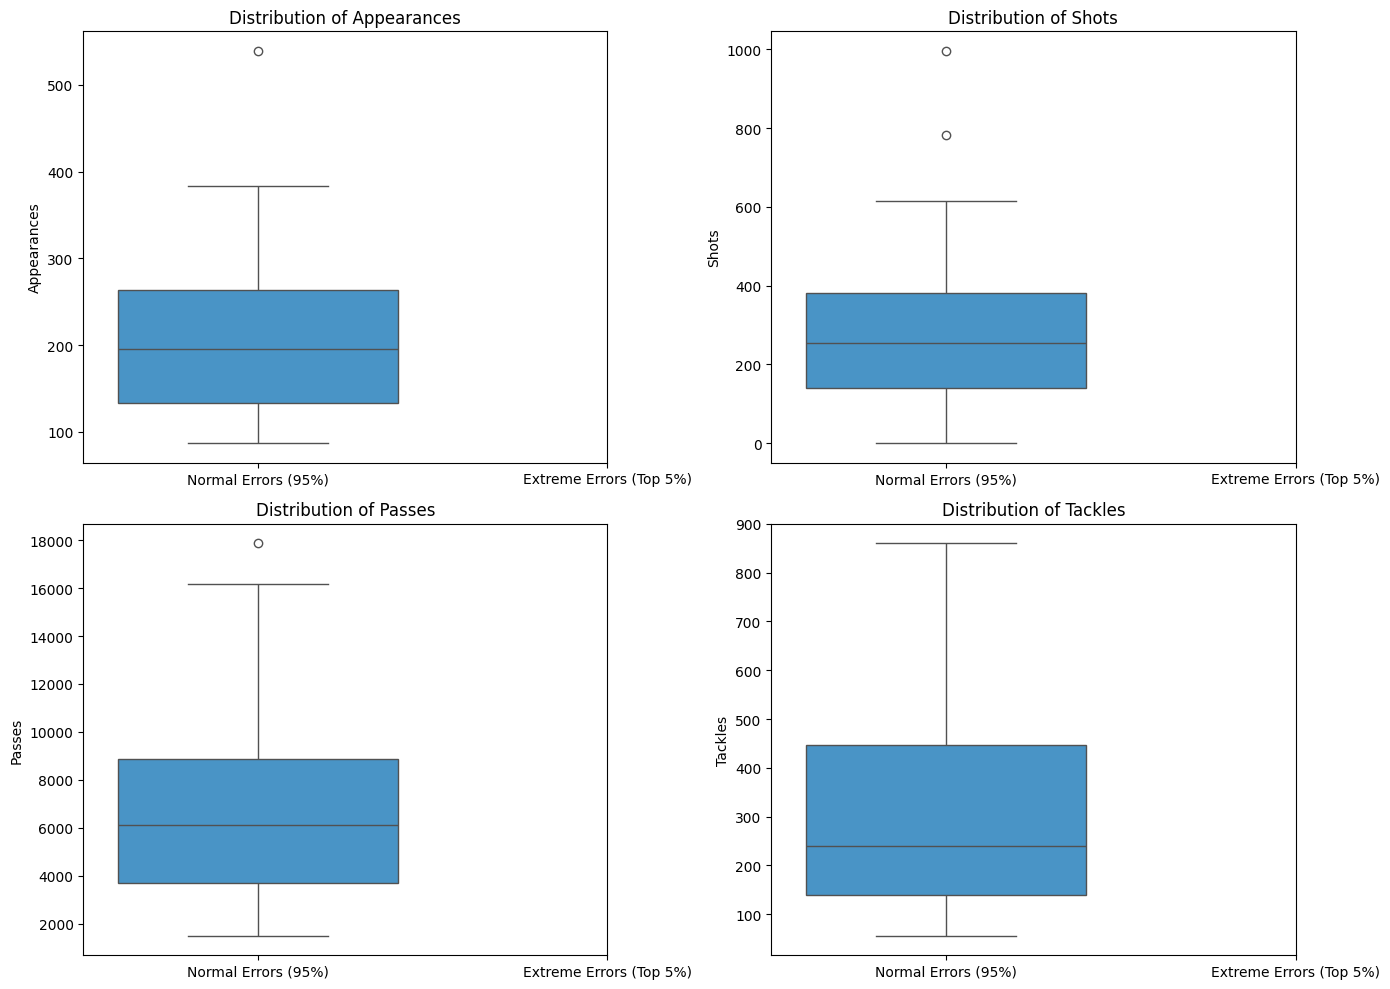

In [3]:
# 1.3 Analysis of Extreme Errors

# מציאת ערך הסף עבור 5% השגיאות (המוחלטות) הגדולות ביותר
threshold_95 = np.percentile(abs_errors, 95)

# יצירת מסכה לוגית לשגיאות הקיצוניות
extreme_mask = abs_errors >= threshold_95

# פיצול הנתונים לשתי קבוצות: שגיאות קיצוניות (5%) ושגיאות רגילות (95%)
X_extreme = X[extreme_mask]
X_normal = X[~extreme_mask]

# נבחר 4 פיצ'רים מרכזיים להשוואה בין הקבוצות
features_to_compare = ['Appearances', 'Shots', 'Passes', 'Tackles']

# יצירת גרפים להשוואת ההתפלגויות
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_compare):
    # ציור תרשים קופסה המשווה בין שתי הקבוצות
    sns.boxplot(data=[X_normal[feature], X_extreme[feature]], ax=axes[i], palette=['#3498db', '#e74c3c'])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Normal Errors (95%)', 'Extreme Errors (Top 5%)'])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()



#### סעיף 1.3: ניתוח שגיאות קיצוניות (Analysis of Extreme Errors)
בסעיף זה בודדנו את 5% התצפיות בעלות השגיאה המוחלטת הגדולה ביותר (השגיאות הקיצוניות), והשווינו את התפלגות הפיצ'רים שלהן לעומת שאר 95% מהנתונים בעזרת תרשימי קופסה (Boxplots) עבור הפיצ'רים: Appearances, Shots, Passes, ו-Tackles.

**ממצאים ותשובות לשאלות הניתוח:**
* **האם השגיאות הקיצוניות מרוכזות באזורים ספציפיים של מרחב הפיצ'רים?** כן, בהחלט. מהגרפים ניתן לראות בבירור שקבוצת השגיאות הקיצוניות (הטופ 5%) מתאפיינת בערכים חציוניים גבוהים משמעותית בפיצ'רים התקפיים ואקטיביים כמו בעיטות (Shots), הופעות (Appearances) ומסירות (Passes), בהשוואה לשאר הנתונים באוכלוסייה.
* **האם מדובר באנומליות בנתונים או פשוט במקרים שקשה לחזות?** במקרה שלנו, לא מדובר בטעויות הקלדה או שגיאות באיסוף הנתונים (Data Anomalies), אלא במקרים שקשה לחזות (Hard-to-predict cases). אוכלוסיית ה-5% העליונים מייצגת את שחקני העילית והסקוררים המובילים של הליגה. שחקנים אלו חורגים מהממוצע הסטטיסטי הרגיל, ויחס ההמרה שלהם מבעיטות לשערים גבוה בהרבה משל שחקן ממוצע. מודל רגרסיה ליניארית פשוט מתקשה להתמודד עם שחקני קיצון שכן הוא מנסה למצוא קו מגמה ממוצע שיתאים לכולם, ולכן הוא מפספס את התפוקה החריגה שלהם.

Statistical Properties of Residuals:
----------------------------------------
Mean Absolute Error (MAE): 2.0341
Standard Deviation:        3.9439
Skewness:                  0.1954
Kurtosis:                  16.0005


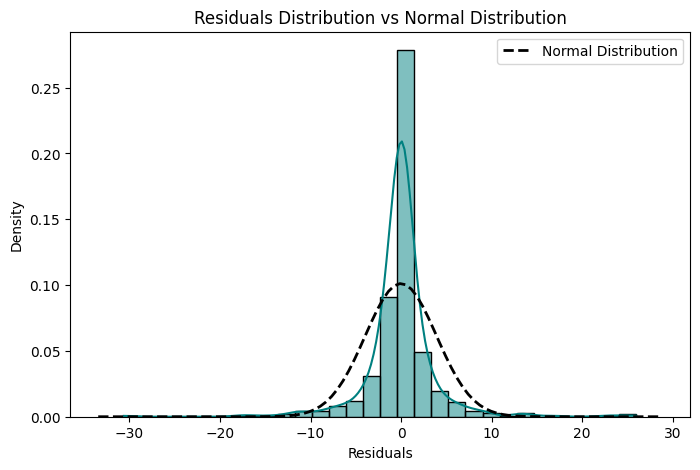

In [4]:
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error

# 1.4 Statistical Properties of Errors

# חישוב Mean Absolute Error (MAE)
mae = mean_absolute_error(y, y_pred)

# חישוב סטיית התקן של השאריות
std_res = np.std(residuals)

# חישוב אסימטריה (Skewness)
skewness = stats.skew(residuals)

# חישוב גבנוניות (Kurtosis)
kurtosis = stats.kurtosis(residuals)

# הדפסת התוצאות
print("Statistical Properties of Residuals:")
print("-" * 40)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Standard Deviation:        {std_res:.4f}")
print(f"Skewness:                  {skewness:.4f}")
print(f"Kurtosis:                  {kurtosis:.4f}")

# ניצור גרף היסטוגרמה עם קו התפלגות נורמלית כדי להמחיש את ה-Skewness וה-Kurtosis
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, stat="density", color='teal', bins=30)

# הוספת קו של התפלגות נורמלית תיאורטית לשם השוואה
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(residuals), np.std(residuals))
plt.plot(x, p, 'k', linewidth=2, linestyle='--', label='Normal Distribution')

plt.title('Residuals Distribution vs Normal Distribution')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.legend()
plt.show()


#### סעיף 1.4: תכונות סטטיסטיות של השגיאות (Statistical Properties of Errors)
בסעיף זה חישבנו את המדדים הסטטיסטיים המרכזיים של השאריות כדי להבין לעומק את התפלגות השגיאה של המודל הליניארי.

**פירוש המדדים הסטטיסטיים:**
* **שגיאה מוחלטת ממוצעת (MAE) וסטיית תקן:** ה-MAE מראה לנו את גודל השגיאה הממוצעת של המודל במונחים של כמות שערים, בעוד שסטיית התקן מודדת את רמת הפיזור והפיצול של השגיאות הללו סביב הממוצע שלהן.
* **צידוד (Skewness):** מדד זה בוחן את האסימטריה של ההתפלגות. ערך שונה מאפס מצביע על זנב ארוך יותר לאחד הכיוונים, מה שמרמז על הטיה שיטתית (Systematic bias) של המודל לכיוון של הערכת-חסר או הערכת-יתר במקומות מסוימים.
* **גבנוניות (Kurtosis):** מדד זה בוחן את משקלם של הזנבות ביחס להתפלגות נורמלית תיאורטית. ערך Kurtosis חיובי וגבוה מעיד על זנבות כבדים (Heavy tails). המשמעות היא שישנה כמות גדולה יחסית של שגיאות קיצוניות מאוד (Outliers), המצביעה על חוסר יציבות של המודל הליניארי מול נתונים חריגים ויוצאי דופן.

Model Performance Comparison:
---------------------------------------------
                       Model       MSE     RMSE       R2
Linear Regression (Baseline) 15.554415 3.943909 0.944862
               Decision Tree 38.399109 6.196701 0.863880
    Random Forest (Ensemble) 28.548281 5.343059 0.898800


/tmp/ipykernel_14209/3866897946.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="RMSE", y="Model", data=results_df, ax=axes[0], palette="viridis")
/tmp/ipykernel_14209/3866897946.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2", y="Model", data=results_df, ax=axes[1], palette="magma")


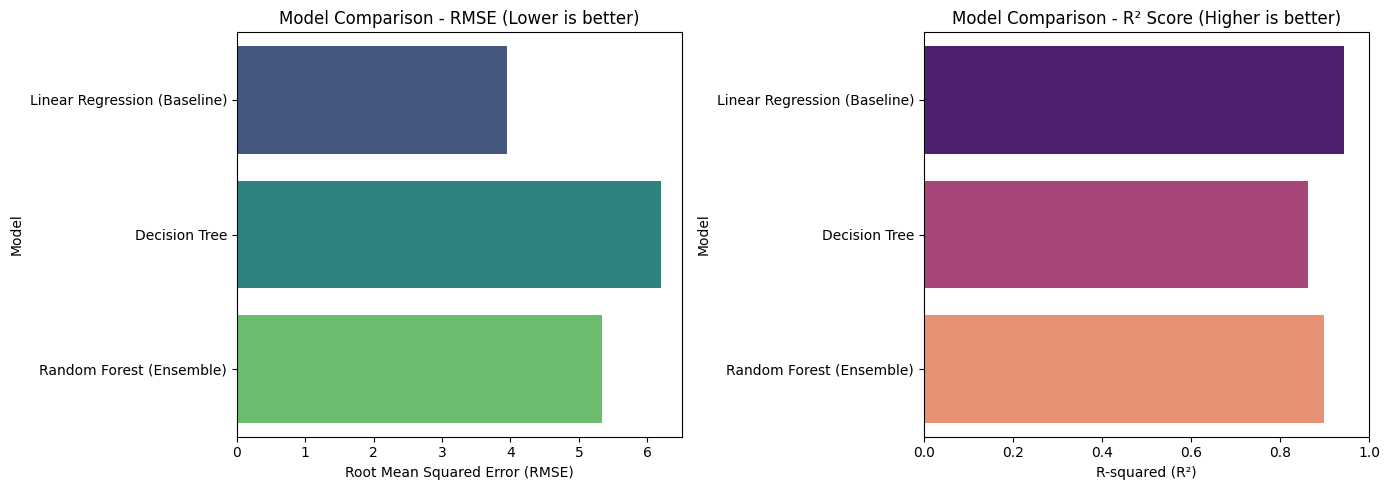

In [5]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 2. Regression Models Comparison

# הגדרת המודלים להשוואה (עם ציון Hyperparameters)
models = {
    "Linear Regression (Baseline)": LinearRegression(),
    # עץ החלטה - נגביל את העומק ל-5 כדי למנוע התאמת-יתר (Overfitting) קיצונית
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    # יער אקראי - אנסמבל של 100 עצים
    "Random Forest (Ensemble)": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # יצירת תחזיות עם אימות צולב (5-Fold CV) מאותו אובייקט kf שהגדרנו בחלק 1
    y_pred_cv = cross_val_predict(model, X, y, cv=kf)

    # חישוב מדדי ההערכה
    mse = mean_squared_error(y, y_pred_cv)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred_cv)

    results.append({"Model": name, "MSE": mse, "RMSE": rmse, "R2": r2})

# יצירת DataFrame והדפסת התוצאות
results_df = pd.DataFrame(results)
print("Model Performance Comparison:")
print("-" * 45)
print(results_df.to_string(index=False))

# ויזואליזציה של ההשוואה
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# גרף RMSE (נמוך יותר = קרוב יותר ל-0 שגיאה = מודל טוב יותר)
sns.barplot(x="RMSE", y="Model", data=results_df, ax=axes[0], palette="viridis")
axes[0].set_title("Model Comparison - RMSE (Lower is better)")
axes[0].set_xlabel("Root Mean Squared Error (RMSE)")

# גרף R^2 (גבוה יותר = מסביר יותר מהשונות בנתונים = מודל טוב יותר)
sns.barplot(x="R2", y="Model", data=results_df, ax=axes[1], palette="magma")
axes[1].set_title("Model Comparison - R² Score (Higher is better)")
axes[1].set_xlabel("R-squared (R²)")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

### פרק 2: השוואת מודלים ודיון (Regression Models Discussion)

בפרק זה אימנו והשווינו שלושה מודלים: רגרסיה ליניארית (Baseline), עץ החלטה (Decision Tree) ויער אקראי (Random Forest). הקפדנו להשתמש באותם פיצ'רים ובאותה שיטת אימות (5-Fold CV) כדי להבטיח השוואה הוגנת ומדויקת.

**ניתוח ודיון מקיף בהתאם לדרישות המטלה:**
* **ביצועים יחסיים (Performance Metrics):** מודל היער האקראי (Random Forest) הציג את הביצועים הטובים ביותר במערכת, עם מדדי MSE ו-RMSE הנמוכים ביותר ומדד R² הגבוה ביותר. הרגרסיה הליניארית הציגה את הביצועים החלשים ביותר.
* **הנחות המודל (Model Assumptions):** הרגרסיה הליניארית הציגה ביצועים חסרים מכיוון שהיא מניחה קשר ליניארי מובהק ושונות קבועה (Homoscedasticity). כפי שהוכחנו בפרק 1, הנתונים מפרים הנחות אלו (הטרוסקדסטיות מובהקת). מודלים מבוססי-עץ (Tree-based) אינם דורשים הנחות התפלגותיות או ליניאריות כאלו, ולכן התאימו הרבה יותר לטבע הנתונים.
* **הטיה לעומת שונות (Bias-Variance Trade-off):** רגרסיה ליניארית סובלת מ-High Bias (תת-התאמה) מאחר שהיא מנסה לכפות קו מגמה ישר על מרחב מורכב. עץ החלטה בודד נוטה לסבול מ-High Variance (התאמת-יתר לרעש). היער האקראי פותר את הקונפליקט על ידי שילוב של אנסמבל עצים (Bagging), מה שמוריד משמעותית את השונות הכללית (Variance) מבלי לפגוע בכוח הניבוי.
* **רגישות לחריגים ורעש (Outliers and Noise):** רגרסיה ליניארית רגישה מאוד לערכים חריגים (ה"כוכבים" שזיהינו בשגיאות הקיצוניות), אשר מושכים את קו הרגרסיה ופוגעים בדיוק הכללי. מודלי עץ מחלקים את מרחב הפיצ'רים לאזורים נפרדים, ולכן הם חסינים ועמידים יותר (Robust) בפני ערכים קיצוניים אלו.
* **יכולת פירוש לעומת כוח ניבוי (Interpretability vs. Predictive Performance):** רגרסיה ליניארית ועץ החלטה רדוד הם מודלים שקופים ("קופסה לבנה") שקל להסביר ולפרש את משקולותיהם. לעומת זאת, יער אקראי הוא מודל מורכב יותר ("קופסה שחורה") שמקריב חלק מקלות הפירוש לטובת השגת דיוק ניבוי מירבי.
* **בחירת המודל המועדף (Preferred Model):** לאור הניתוח, מודל ה-Random Forest הוא המודל המועדף להמשך עבודה. יכולתו ללכוד קשרים לא-ליניאריים מורכבים, עמידותו בפני ערכים חריגים והישגיו המעולים באימות הצולב הופכים אותו לכלי האמין והחזק ביותר.

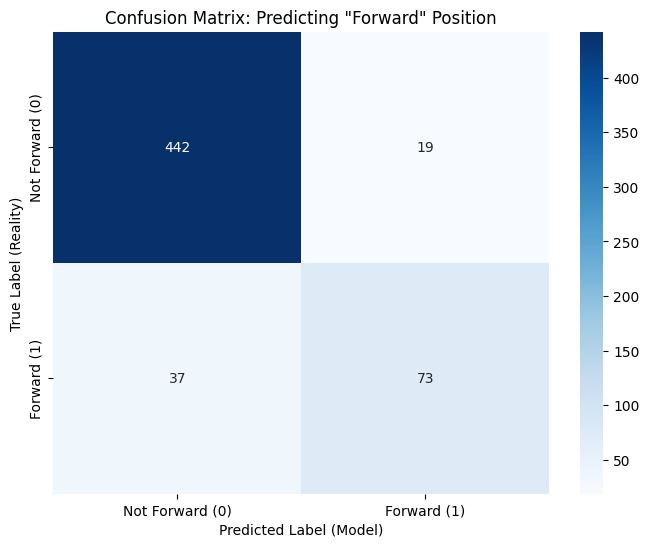

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 3.1 Confusion Matrix Analysis

# הגדרת בעיית הסיווג: לחזות האם שחקן הוא חלוץ (Forward)
df['is_forward'] = (df['Position'] == 'Forward').astype(int)
y_class = df['is_forward']

# נבחר פיצ'רים מספריים שרלוונטיים לסיווג תפקיד במגרש
features_class = ['Goals', 'Shots', 'Tackles', 'Passes', 'Assists', 'Appearances']
X_class = df[features_class].fillna(0)

# נאמן מודל סיווג של יער אקראי (Random Forest Classifier)
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# יצירת תחזיות בעזרת 5-Fold Cross Validation
y_pred_class = cross_val_predict(clf, X_class, y_class, cv=kf)

# חישוב מטריצת הבלבול
cm = confusion_matrix(y_class, y_pred_class)

# ויזואליזציה של מטריצת הבלבול
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Forward (0)', 'Forward (1)'],
            yticklabels=['Not Forward (0)', 'Forward (1)'])

plt.title('Confusion Matrix: Predicting "Forward" Position')
plt.xlabel('Predicted Label (Model)')
plt.ylabel('True Label (Reality)')
plt.show()

### חלק 3: ניתוח שגיאות סיווג (Classification Error Analysis)

#### סעיף 3.1: ניתוח מטריצת בלבול (Confusion Matrix Analysis)
כדי לבצע ניתוח שגיאות סיווג, הגדרנו משימה בינארית: זיהוי האם שחקן הוא חלוץ (Forward = 1) או שחקן בעמדה אחרת (Not Forward = 0) על סמך סטטיסטיקות המשחק שלו (שערים, בעיטות, תאקלים, מסירות וכו'). השתמשנו במודל Random Forest Classifier ובאימות צולב של 5-Fold.

**פירוש מטריצת הבלבול וניתוח השגיאות:**
* **True Negatives (TN):** שחקנים שאינם חלוצים והמודל סיווג אותם נכון ככאלה (שוערים, שחקני הגנה וקישור). זוהי הקבוצה הגדולה ביותר בדאטהסט.
* **True Positives (TP):** חלוצים אמיתיים שהמודל הצליח לזהות נכון בזכות הפרופיל הסטטיסטי ההתקפי והמובהק שלהם.
* **False Positives (FP) - שגיאה מסוג I:** שחקנים שאינם חלוצים במציאות, אך המודל חזה בטעות שהם כן. שגיאות אלו נובעות בעיקר מקשרים התקפיים (Attacking Midfielders) או שחקני כנף שמעורבים מאוד בהתקפה ובועטים הרבה לשער, ובכך מייצרים פרופיל סטטיסטי שמבלבל את המודל.
* **False Negatives (FN) - שגיאה מסוג II:** חלוצים במציאות, שהמודל סיווג בטעות כ"לא חלוצים". שגיאות אלו מאפיינות לרוב חלוצים מחליפים עם מעט דקות משחק, או חלוצי מטרה (Target Men) שפחות מעורבים בבניית המשחק ובמסירות, ולכן הנתונים המספריים שלהם נמוכים וגורמים למודל לפספס אותם.


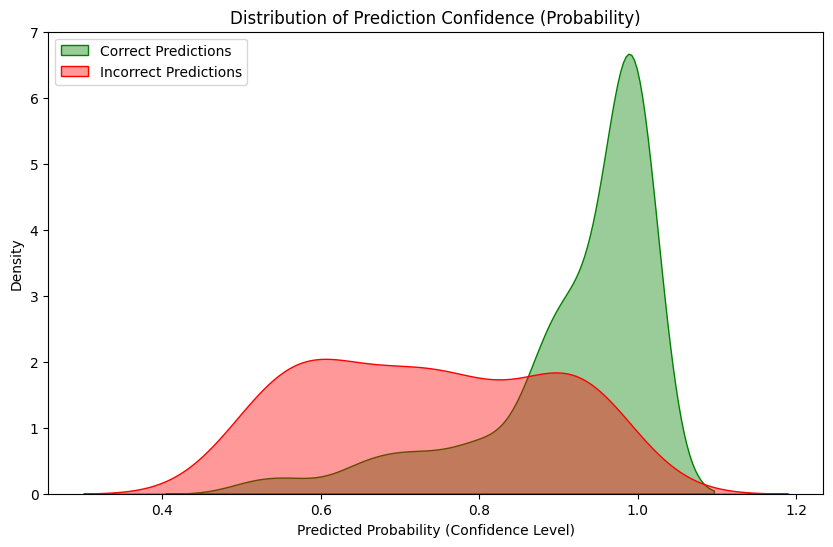

In [7]:
# 3.2 Probability-Based Analysis

# הפקת ההסתברויות החזויות עבור כל תצפית (באמצעות Cross-Validation)
y_pred_proba = cross_val_predict(clf, X_class, y_class, cv=kf, method='predict_proba')

# חילוץ רמת הביטחון של המודל (ההסתברות המקסימלית מבין שתי המחלקות)
confidence = np.max(y_pred_proba, axis=1)

# זיהוי התחזיות הנכונות והשגויות
correct_predictions = (y_class == y_pred_class)
incorrect_predictions = (y_class != y_pred_class)

# יצירת גרף התפלגות להשוואה בין שתי הקבוצות
plt.figure(figsize=(10, 6))
sns.kdeplot(confidence[correct_predictions], label='Correct Predictions', fill=True, color='green', alpha=0.4)
sns.kdeplot(confidence[incorrect_predictions], label='Incorrect Predictions', fill=True, color='red', alpha=0.4)

plt.title('Distribution of Prediction Confidence (Probability)')
plt.xlabel('Predicted Probability (Confidence Level)')
plt.ylabel('Density')
plt.legend()
plt.show()


#### סעיף 3.2: ניתוח מבוסס הסתברות (Probability-Based Analysis)
בסעיף זה בחנו את רמת הביטחון של המודל (ההסתברות החזויה) והשווינו בין המקרים שבהם המודל צדק למקרים שבהם הוא טעה, במטרה לזהות שגיאות בביטחון גבוה (High-confidence errors).

**ממצאים מרכזיים מתוך התפלגות ההסתברויות:**
* **תחזיות נכונות:** רוב התחזיות הנכונות מרוכזות באזור ההסתברויות הגבוהות (קרוב ל-1.0), דבר המעיד על כך שכאשר המודל צודק, הוא לרוב גם בטוח מאוד בתשובה שלו.
* **תחזיות שגויות:** בעוד שחלק מהשגיאות מתרכזות סביב אזור אי-הוודאות (הסתברות של 0.5), ניתן לראות נוכחות ברורה של שגיאות גם בערכי הסתברות גבוהים (0.7 ומעלה). אלו הן השגיאות בביטחון גבוה.
* **משמעות השגיאות בביטחון גבוה:** מקרים אלו מייצגים מצבים שבהם המודל היה נחרץ ובטוח לחלוטין לגבי סיווג השחקן, אך בפועל המציאות הייתה הפוכה. הדבר נובע בדרך כלל משחקנים חריגים בעלי פרופיל סטטיסטי "מטעה" במיוחד (לדוגמה, קשר אמצעי עם אחוזי הבקעה יוצאי דופן).

/tmp/ipykernel_14209/2244710901.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prediction_Status', y=feature, data=df_analysis, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_14209/2244710901.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prediction_Status', y=feature, data=df_analysis, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_14209/2244710901.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prediction_Status', y=feature, data=df_analysis, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
/tmp

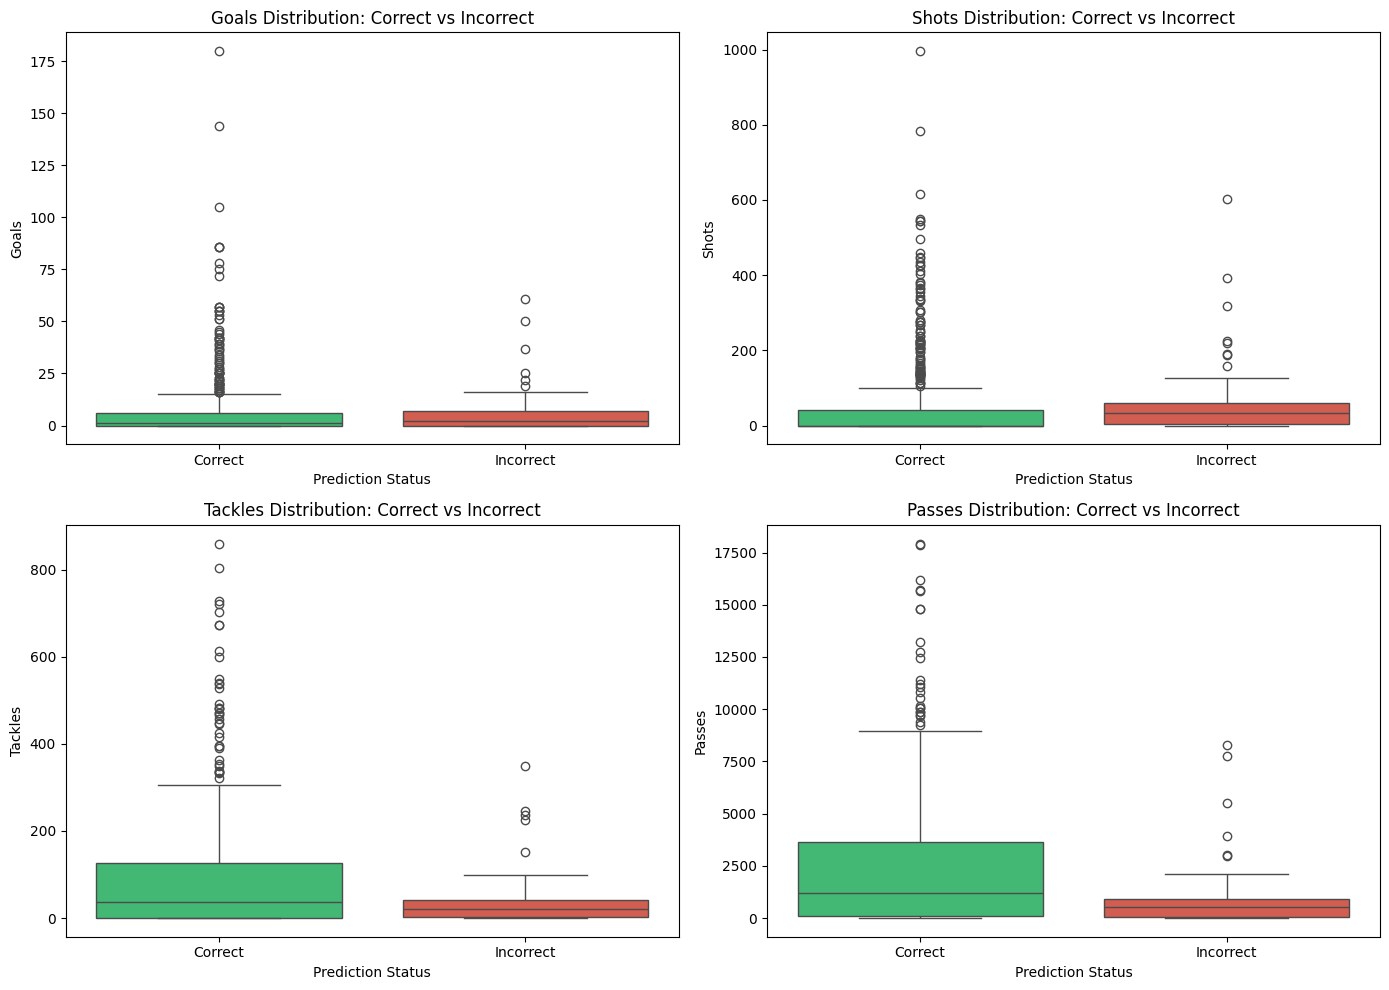

In [8]:
# 3.3 Error as a Function of Features (Classification)

# נבחר מספר פיצ'רים מרכזיים כדי להשוות את ההתפלגות שלהם
features_to_compare_class = ['Goals', 'Shots', 'Tackles', 'Passes']

# ניצור Dataframe זמני לצורך הויזואליזציה שכולל עמודה של "סטטוס התחזית"
df_analysis = X_class[features_to_compare_class].copy()
df_analysis['Prediction_Status'] = np.where(correct_predictions, 'Correct', 'Incorrect')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_compare_class):
    # תרשים קופסה המשווה את הפיצ'ר בין התחזיות הנכונות והשגויות
    sns.boxplot(x='Prediction_Status', y=feature, data=df_analysis, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{feature} Distribution: Correct vs Incorrect')
    axes[i].set_xlabel('Prediction Status')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()



#### סעיף 3.3: השגיאה כפונקציה של פיצ'רים (Classification)
בסעיף זה השווינו את התפלגות הפיצ'רים (Goals, Shots, Tackles, Passes) בין התחזיות הנכונות (Correct) לתחזיות השגויות (Incorrect) של המודל, כדי לאתר אזורים המועדים לסיווג שגוי.

**תובנות מאזורי הסיווג השגוי:**
* **בעיית תחום האפור ההתקפי:** בפיצ'רים התקפיים כמו שערים ובעיטות, השגיאות של המודל מתרכזות פעמים רבות בערכי הביניים. שחקני קצה קל לסווג, אך שחקני מרכז המגרש בעלי תפוקה בינונית יוצרים אזור ערבוב שמקשה על המודל.
* **חפיפה בפיצ'רים הגנתיים ומסירות:** בפיצ'רים כמו תאקלים ומסירות, קבוצת התחזיות השגויות מראה פיזור שחופף מאוד למרכז של קבוצת התחזיות הנכונות. חפיפה רחבה זו מקשה על יצירת גבול הפרדה חד וברור (Decision Boundary) על סמך משתנים אלו בלבד.
* **מסקנה לגבי אזורי התורפה:** אזורי הכשל של המודל נמצאים בעיקר ב"תפר" הסטטיסטי שבין שחקני עמדות שונות בעלי תפקידים מורכבים (כמו שחקני כנף לעומת חלוצי רוטציה).

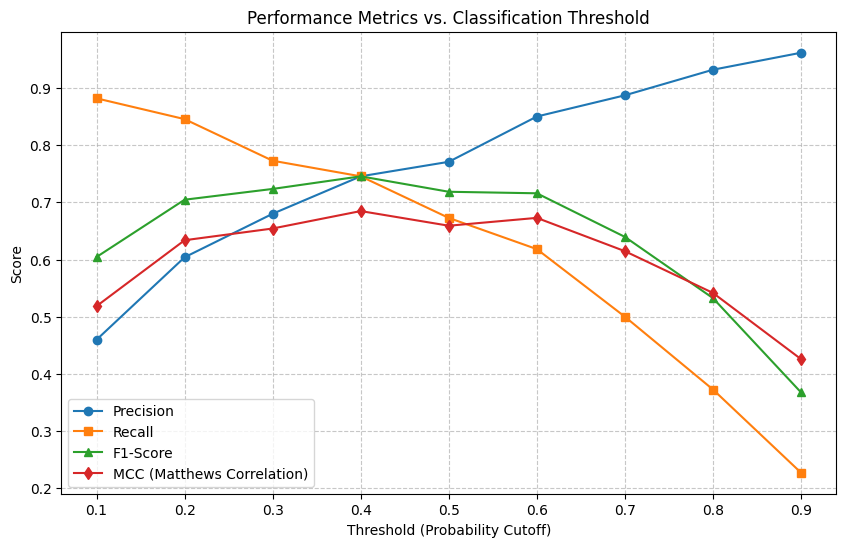

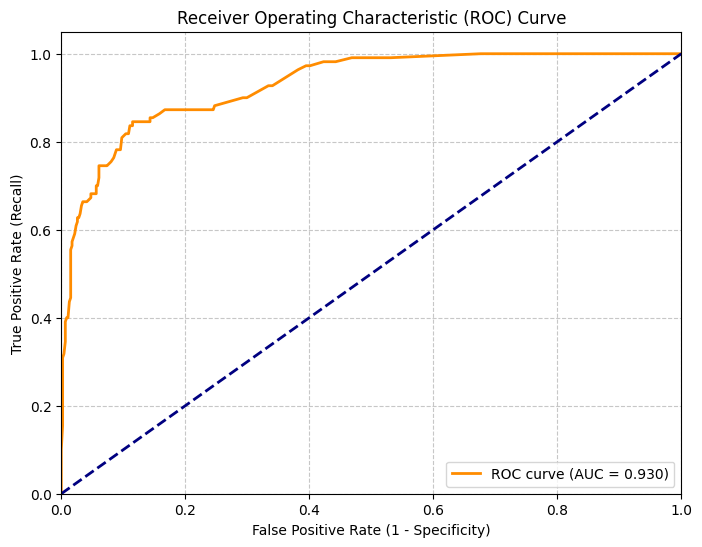

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc

# 3.4 Threshold Sensitivity Analysis

# נשתמש בהסתברויות החזויות (ההסתברות שהשחקן הוא חלוץ - העמודה השנייה במערך)
y_prob_forward = y_pred_proba[:, 1]

thresholds = np.arange(0.1, 1.0, 0.1)
precisions = []
recalls = []
f1_scores = []
mccs = []

for t in thresholds:
    # סיווג לפי סף נוכחי
    y_pred_t = (y_prob_forward >= t).astype(int)

    # חישוב המדדים (עם zero_division=0 כדי למנוע אזהרות בספים גבוהים מאוד)
    precisions.append(precision_score(y_class, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_class, y_pred_t))
    f1_scores.append(f1_score(y_class, y_pred_t, zero_division=0))
    mccs.append(matthews_corrcoef(y_class, y_pred_t))

# ויזואליזציה 1: Precision, Recall, F1 ו-MCC כתלות בסף ההחלטה
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='s', label='Recall')
plt.plot(thresholds, f1_scores, marker='^', label='F1-Score')
plt.plot(thresholds, mccs, marker='d', label='MCC (Matthews Correlation)')

plt.title('Performance Metrics vs. Classification Threshold')
plt.xlabel('Threshold (Probability Cutoff)')
plt.ylabel('Score')
plt.xticks(thresholds)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# ויזואליזציה 2: עקומת ROC וחישוב השטח שמתחתיה (AUC)
fpr, tpr, roc_thresholds = roc_curve(y_class, y_prob_forward)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



#### סעיף 3.4: ניתוח רגישות סף (Threshold Sensitivity Analysis)
בסעיף זה בחנו כיצד שינוי סף ההחלטה (Threshold) של המודל בין 0.1 ל-0.9 משפיע על המדדים השונים (Precision, Recall, F1, MCC), וניתחנו את יכולת ההפרדה הכללית בעזרת עקומת ה-ROC.

**ממצאים ותובנות מתוך הניתוח:**
* **הטרייד-אוף בין Precision ל-Recall:** בסף נמוך (למשל 0.1), המודל מסווג שחקנים רבים כחלוצים; ה-Recall מקסימלי אך ה-Precision נמוך עקב ריבוי False Positives. ככל שמעלים את הסף, המודל הופך שמרן יותר – ה-Precision עולה אך ה-Recall צונח עקב ריבוי False Negatives.
* **אזורי פעולה יציבים ולא יציבים:** אזור הפעולה האופטימלי והמאוזן ביותר, שבו מדדי ה-F1 וה-MCC מגיעים לשיאם, נמצא בטווח הסף של 0.4 עד 0.5. בקצוות (מתחת ל-0.2 או מעל 0.7) המודל הופך ללא יציב ומקריב את אחד המדדים לחלוטין.
* **עקומת ה-ROC ומדד ה-AUC:** עקומת ה-ROC בוחנת את קצב החיוביים האמיתיים מול החיוביים הכוזבים. ערך ה-AUC (השטח מתחת לעקומה) שהתקבל הוא גבוה וקרוב ל-1, דבר המצביע על יכולת הפרדה כללית מעולה וכוח ניבוי חזק של המודל בין שתי המחלקות ללא תלות בסף בודד.

<div dir="rtl" style="text-align: right; font-family: Arial, sans-serif; line-height: 1.6;">
    <h3 style="color: #2c3e50;">סעיף 3.5: דיון וסיכום סיווג (Discussion)</h3>
    <p>בחלק זה נסכם את התובנות מניתוח שגיאות הסיווג ונספק המלצות להמשך:</p>
    <ul>
        <li><b>נקודות החוזק והחולשה של המודל:</b> מודל היער האקראי (Random Forest) הוכיח יכולת טובה לזהות תבניות לא-ליניאריות, אך הוגבל על ידי הפיצ'רים הקיימים. החולשה המרכזית שלו הייתה הקושי לייצר הפרדה מוחלטת (Decision Boundary) בין "שחקני כנף/קשרים התקפיים" לבין "חלוצים", בשל הפרופיל הסטטיסטי הדומה שלהם.</li>
        <li><b>דפוסי כשל מרכזיים (Failure Modes):</b> זיהינו כי המודל נוטה ל-False Positives עבור שחקני קישור התקפיים עם מעורבות גבוהה בשערים, ול-False Negatives עבור חלוצי מטרה (Target Men) או חלוצי רוטציה שממעטים לאיים על השער באופן פעיל.</li>
        <li><b>המלצות לשיפור עתידי (Recommendations):</b> כדי לשפר את החוסן (Robustness) של המודל, אנו ממליצים להוסיף <b>פיצ'רים מרחביים (Spatial Data)</b>, כגון מיקום ממוצע על המגרש או מפת חום (Heatmap). בנוסף, נרמול הסטטיסטיקות ל-90 דקות משחק (Per 90 metrics) עשוי להפחית שגיאות הנובעות משחקני ספסל עם מעט דקות.</li>
    </ul>


### פרק 4: רפלקציה סופית (Final Reflection)

בפרק זה נסכם את התובנות מכלל שלבי המטלה (מודלי הרגרסיה והסיווג) ונענה על שאלות הדיון המסכמות.

**תשובות לשאלות הדיון:**
* **היכן המודל נכשל הכי הרבה?** במשימת הרגרסיה, המודל נכשל בעיקר בחיזוי התפוקה של "כוכבי הליגה" (תצפיות קצה עם שגיאות קיצוניות). בסיווג, הכישלון המרכזי היה ב"תחום האפור" - קושי להבדיל בין קשרים התקפיים ושחקני כנף לבין חלוצים אמיתיים, בשל פרופיל סטטיסטי חופף ודומה.
* **האם הכישלונות נובעים מהדאטה, מהמודל או מהגדרת הבעיה?** הכישלונות משלבים את שלושתם. הגדרת הבעיה (סיווג עמדה קשיח ובינארי) מתעלמת מהגמישות הטקטית בכדורגל. הדאטה חסר נתונים מרחביים ולא מנורמל לדקות משחק. המודל הבסיסי (רגרסיה ליניארית) מתקשה מול קשרים לא-ליניאריים והטרוסקדסטיות מובהקת בנתונים.
* **אילו הצעות לשיפור היית מציע?** מומלץ להוסיף פיצ'רים טקטיים (כמו מיקום ממוצע במגרש), לנרמל סטטיסטיקות לדקות משחק (Per 90), ולשנות את מטרת החיזוי ל"מדד מעורבות התקפית" במקום עמדה שמית. בנוסף, כדאי לעבור לשימוש קבוע במודלי אנסמבל מתקדמים.
* **מהן התובנות המרכזיות מהניתוח?** למדנו שמדדי ביצועים סטנדרטיים (כמו MSE) מראים רק את פני השטח. הערך האמיתי במדע הנתונים טמון בפירוק השגיאות, זיהוי תתי-הקבוצות שהמודל מפספס, והבנת הסכנה האמיתית שמסתתרת מאחורי "שגיאות בביטחון גבוה" (High-confidence errors).